In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading in the dataset
df = pd.read_csv("paddydataset.csv")

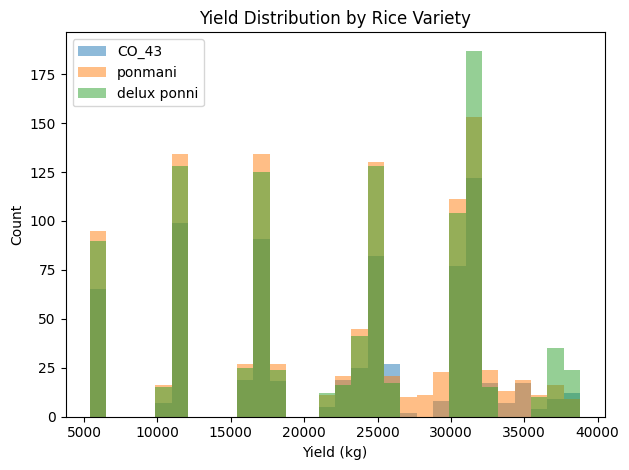

In [10]:
# Creating plot to visualize yield distribution by variety
varieties = df["Variety"].unique()

for v in varieties:
    subset = df[df["Variety"] == v]["Paddy yield(in Kg)"]
    plt.hist(subset, bins=30, alpha=0.5, label=v)

plt.xlabel("Yield (kg)")
plt.ylabel("Count")
plt.title("Yield Distribution by Rice Variety")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Bootstrap CIs for each variety mean using 10,000 resamples
np.random.seed(42)
n_boot = 10000
boot_results = {}

for variety in df["Variety"].unique():
    group = df[df["Variety"] == variety]["Paddy yield(in Kg)"].values
    boot_means = [
        np.mean(np.random.choice(group, size=len(group), replace=True))
        for _ in range(n_boot)
    ]
    boot_results[variety] = {
        "mean": round(np.mean(group), 2),
        "ci": (round(np.percentile(boot_means, 2.5), 2), round(np.percentile(boot_means, 97.5), 2))
    }

for v, res in boot_results.items():
    print(f"{v}: mean = {res['mean']}, 95% CI = {res['ci']}")

CO_43: mean = 22540.66, 95% CI = (np.float64(21876.46), np.float64(23202.34))
ponmani: mean = 22411.11, 95% CI = (np.float64(21866.24), np.float64(22951.73))
delux ponni: mean = 22614.45, 95% CI = (np.float64(22017.24), np.float64(23187.17))


In [12]:
# One-way ANOVA to test whether variety significantly affects mean paddy yield
from scipy import stats
groups = [
    df[df["Variety"] == v]["Paddy yield(in Kg)"].values
    for v in df["Variety"].unique()
]

f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-statistic: {f_stat:.4f}")
print(f"p-value:     {p_value:.4f}")


F-statistic: 0.1285
p-value:     0.8794


In [13]:
# Computing SD within each variety to assess variability
for v in df["Variety"].unique():
    group = df[df["Variety"] == v]["Paddy yield(in Kg)"].values
    print(f"{v}: SD = {np.std(group):.2f}")

CO_43: SD = 9185.61
ponmani: SD = 9059.77
delux ponni: SD = 9350.82


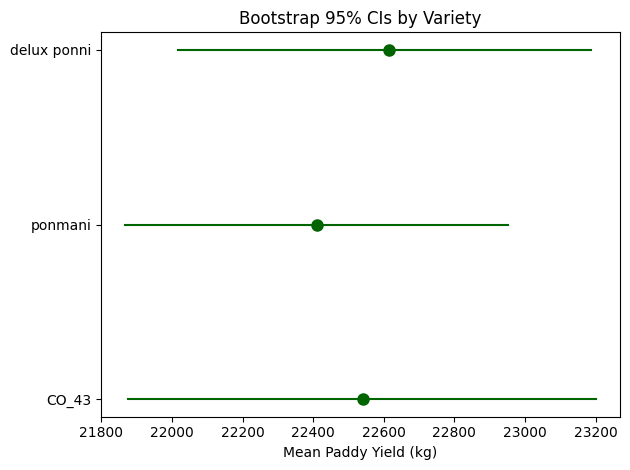

In [23]:
# Forest plot of bootstrap CIs by variety
varieties = list(boot_results.keys())
means = [boot_results[v]["mean"] for v in varieties]
ci_low = [boot_results[v]["ci"][0] for v in varieties]
ci_high = [boot_results[v]["ci"][1] for v in varieties]

for i, v in enumerate(varieties):
    plt.plot([ci_low[i], ci_high[i]], [i, i], color="darkgreen")
    plt.plot(means[i], i, "o", color="darkgreen", markersize=8)
plt.yticks(range(len(varieties)), varieties)
plt.xlabel("Mean Paddy Yield (kg)")
plt.title("Bootstrap 95% CIs by Variety")
plt.tight_layout()
plt.show()